# 🚀 Calorie Prediction with XGBoost and RMSLE

In [1]:
!pip install xgboost

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
from xgboost import XGBRegressor

In [3]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [4]:
train

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
749995,749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0


In [5]:
test

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5
...,...,...,...,...,...,...,...,...
249995,999995,female,56,159.0,62.0,6.0,85.0,39.4
249996,999996,male,32,202.0,101.0,3.0,84.0,38.4
249997,999997,female,31,164.0,64.0,14.0,98.0,40.1
249998,999998,female,62,158.0,61.0,25.0,106.0,40.7


In [6]:
train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [8]:
train.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [9]:
train.isnull().sum()

,0
id,0
Sex,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [10]:
train.duplicated().sum()

np.int64(0)

<Axes: ylabel='Calories'>

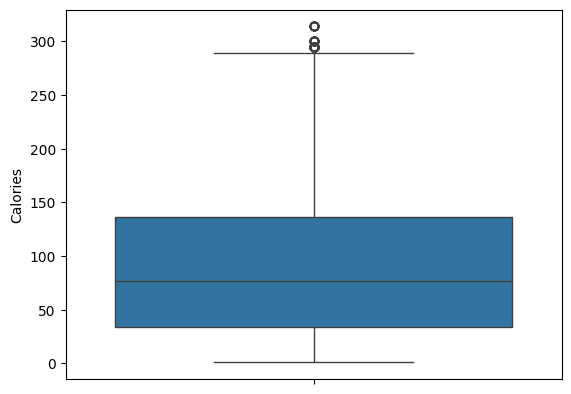

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(train['Calories'])

In [12]:
cols_to_check = ['Age', 'Height', 'Weight', 'Body_Temp', 'Heart_Rate', 'Duration', 'Calories']

outlier_summary = {}

for col in cols_to_check:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_exist = train[(train[col] < lower_bound) | (train[col] > upper_bound)].shape[0] > 0
    outlier_summary[col] = 'Yes' if outliers_exist else 'No'
print(outlier_summary)


{'Age': 'No', 'Height': 'Yes', 'Weight': 'Yes', 'Body_Temp': 'Yes', 'Heart_Rate': 'Yes', 'Duration': 'No', 'Calories': 'Yes'}


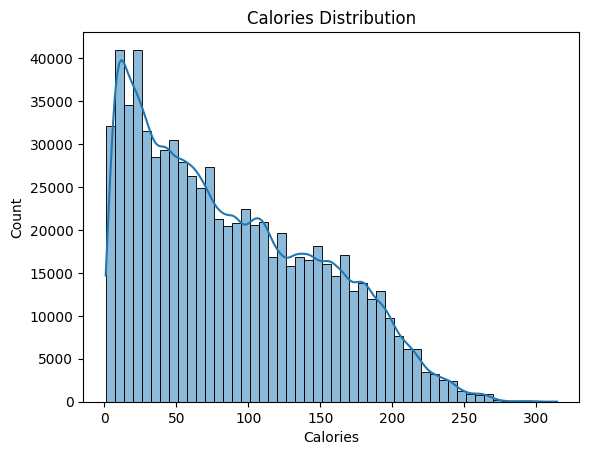

In [13]:
sns.histplot(train['Calories'], bins=50, kde=True)
plt.xlabel("Calories")
plt.title("Calories Distribution")
plt.show()


<Axes: xlabel='Height', ylabel='Density'>

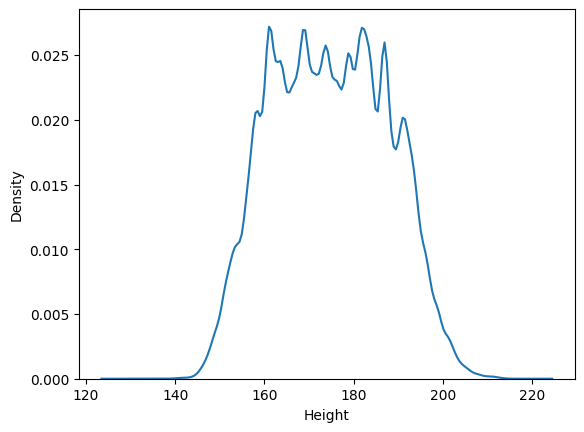

In [14]:
sns.kdeplot(train["Height"])

In [15]:
from scipy.stats.mstats import winsorize

In [16]:
train['Height'] = winsorize(train['Height'], limits=[0.01, 0.01])
train['Weight'] = winsorize(train['Weight'], limits=[0.01, 0.01])
train['Heart_Rate'] = winsorize(train['Heart_Rate'], limits=[0.01, 0.01])
train['Calories'] = winsorize(train['Calories'], limits=[0.01, 0.01])

<Axes: xlabel='Height', ylabel='Density'>

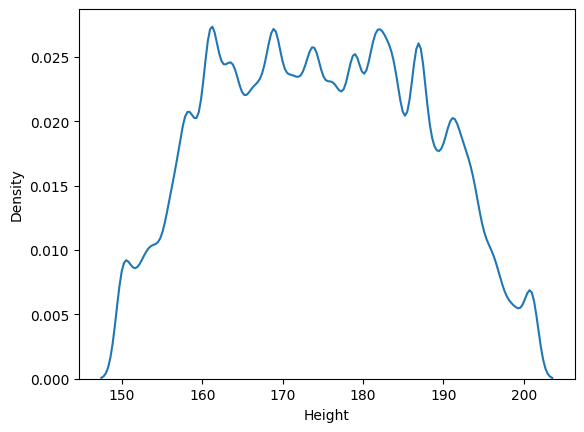

In [17]:
sns.kdeplot(train["Height"])

<Axes: xlabel='Weight', ylabel='Density'>

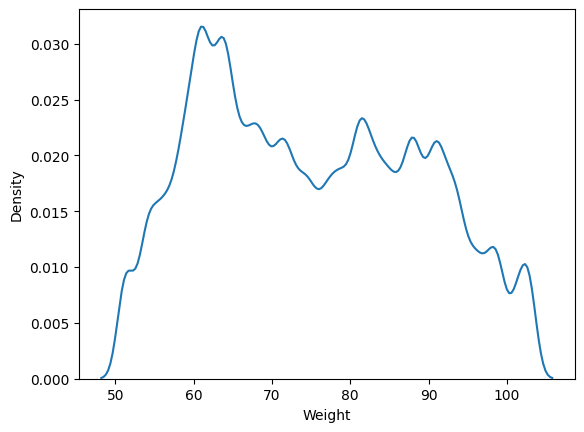

In [18]:
sns.kdeplot(train["Weight"])

<Axes: xlabel='Heart_Rate', ylabel='Density'>

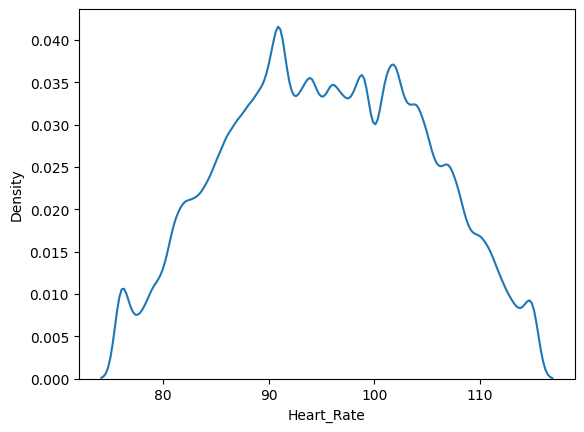

In [19]:
sns.kdeplot(train["Heart_Rate"])

<Axes: xlabel='Calories', ylabel='Density'>

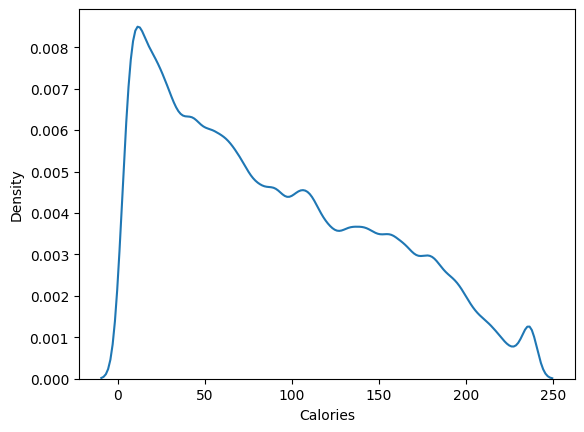

In [20]:
sns.kdeplot(train["Calories"])

<Axes: ylabel='Calories'>

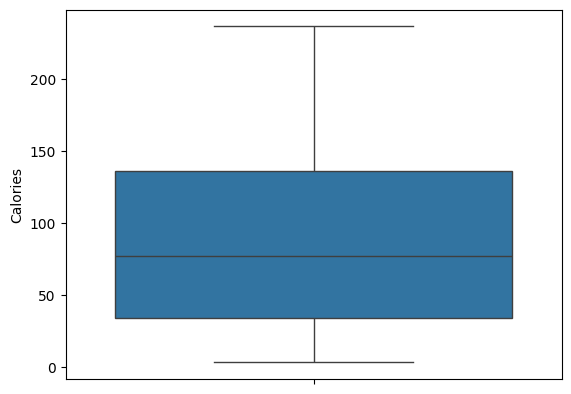

In [21]:
sns.boxplot(train['Calories'])

In [22]:
print("Skewness:", train['Height'].skew())
print("Skewness:", train['Weight'].skew())
print("Skewness:", train['Heart_Rate'].skew())
print("Skewness:", train['Calories'].skew())

Skewness: 0.040700652173755
Skewness: 0.19127503105954402
Skewness: 0.0022469102133303148
Skewness: 0.5094863879265144


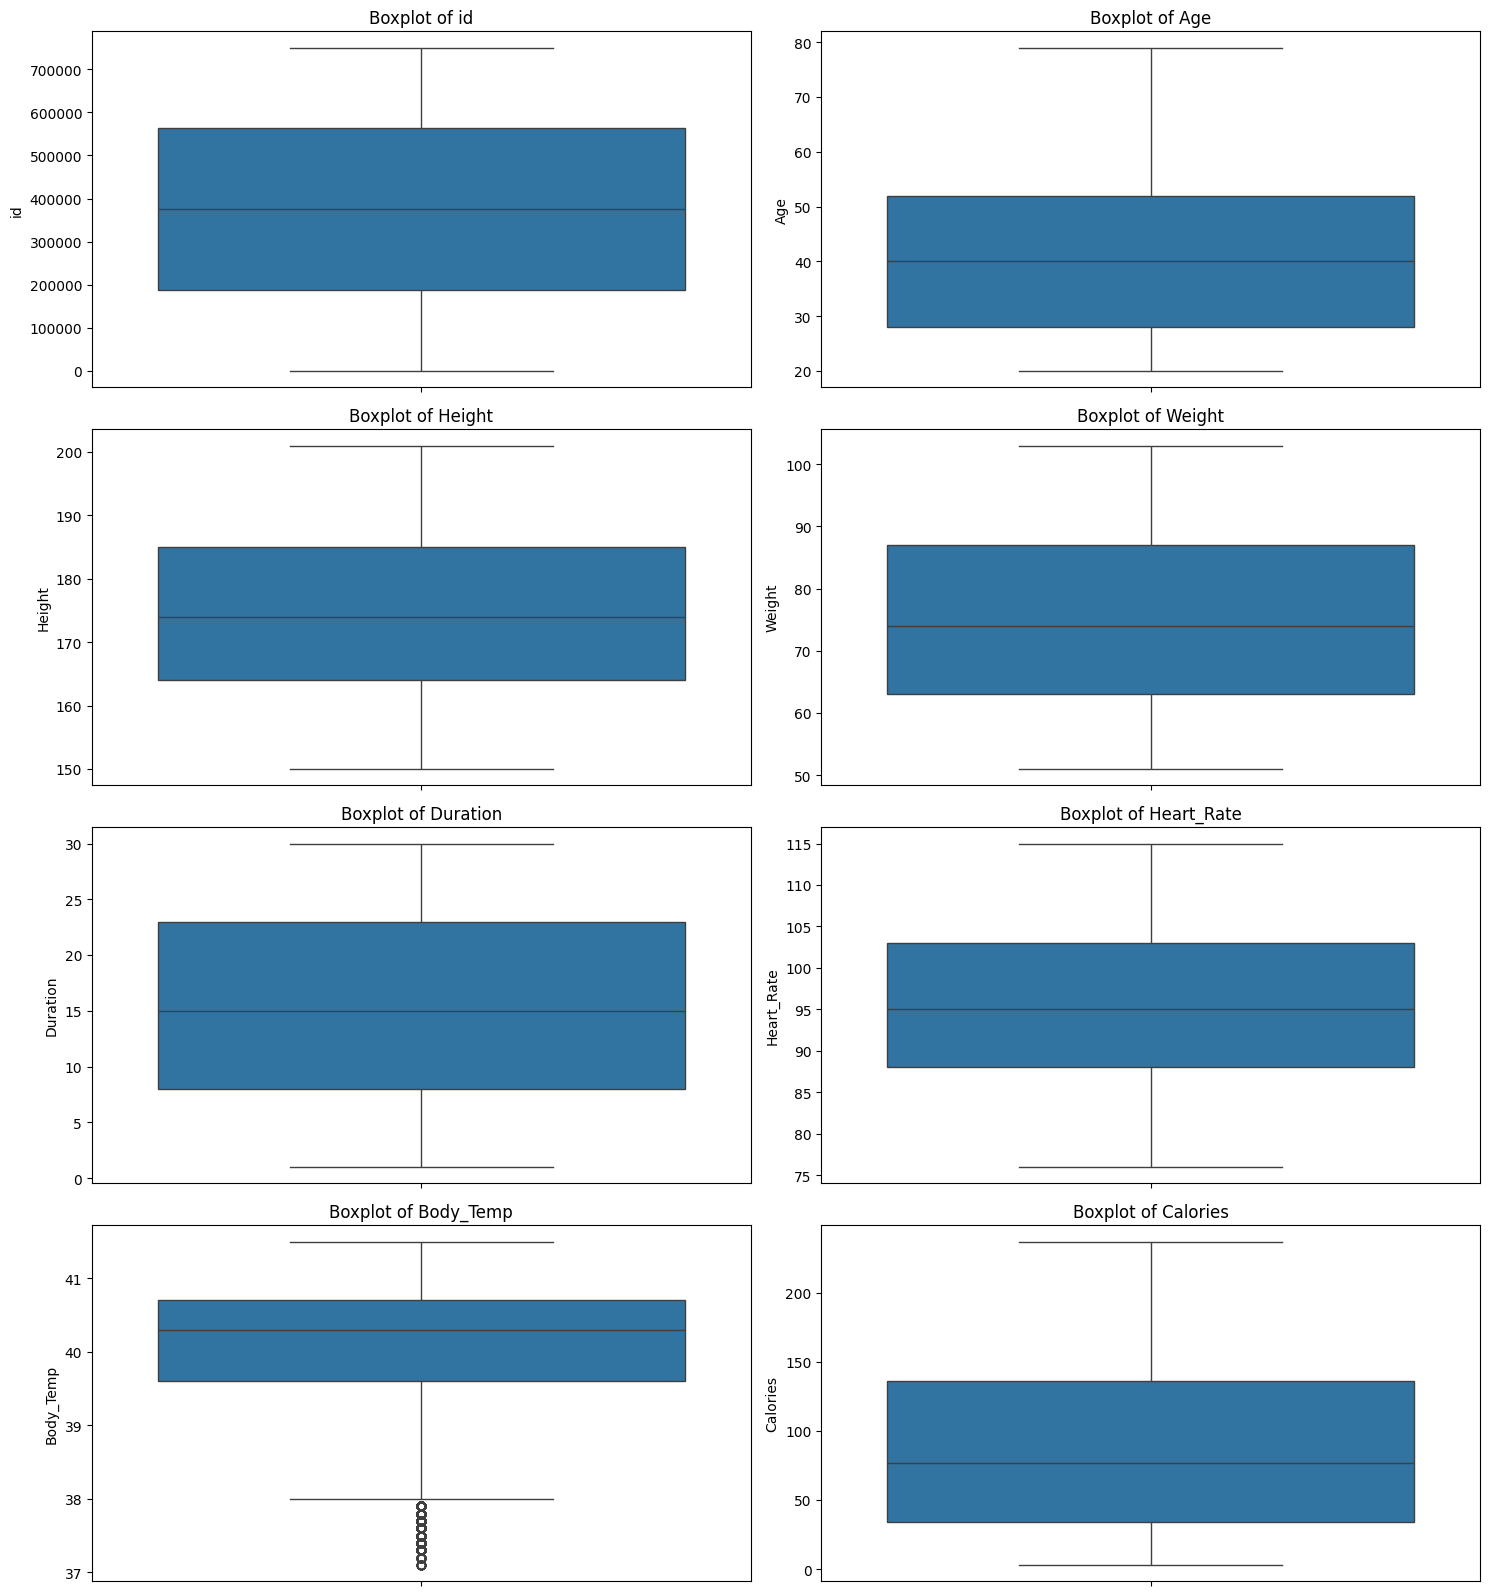

In [23]:
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols)//2 + 1, 2, i)
    sns.boxplot(y=train[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

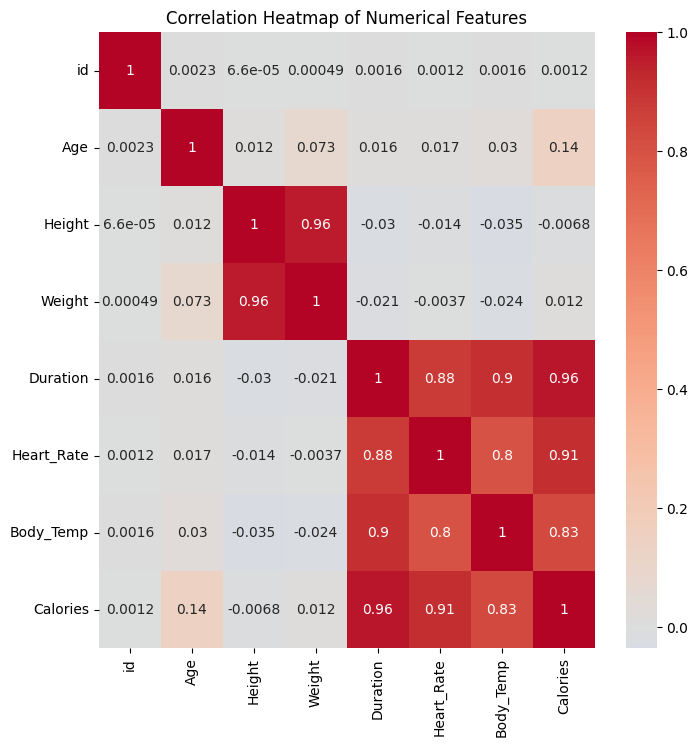

In [24]:
# Correlation heatmap
plt.figure(figsize=(8, 8))
corr_matrix = train[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

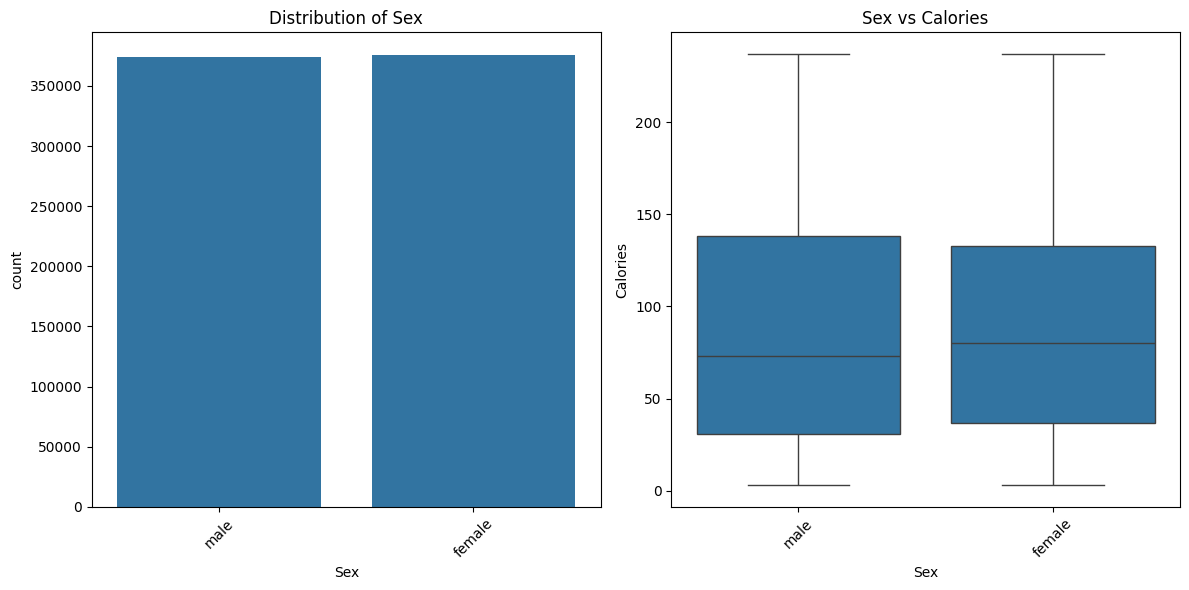


Cross-tabulation for Sex:
Calories  3.0    4.0    5.0    6.0    7.0    8.0    9.0    10.0   11.0   \
Sex                                                                       
female     2294   3047   1296   1890   4101   3570   3132   2746   3422   
male       5537   3306   2946   3414   4249   3346   3518   3439   3560   

Calories  12.0   ...  228.0  229.0  230.0  231.0  232.0  233.0  234.0  235.0  \
Sex              ...                                                           
female     3250  ...     54     52     66     97     64     21     37     36   
male       3701  ...    352    453    706    435    365    450    318    314   

Calories  236.0  237.0  
Sex                     
female       36    177  
male        419   7344  

[2 rows x 235 columns]


In [25]:
# For each categorical column, analyze distribution and relationship with target
categorical_cols = train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(12, 6))

    # Countplot
    plt.subplot(1, 2, 1)
    sns.countplot(data=train, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

    # Boxplot against a numerical target (assuming 'Calories' is target)
    if 'Calories' in numerical_cols:
        plt.subplot(1, 2, 2)
        sns.boxplot(data=train, x=col, y='Calories')
        plt.title(f"{col} vs Calories")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Cross-tabulation if binary categorical
    if train[col].nunique() == 2:
        print(f"\nCross-tabulation for {col}:")
        print(pd.crosstab(train[col], train['Calories']))

In [26]:
train['bmi'] = train['Weight'] / ((train['Height']/100)**2)

In [27]:
train['Weight_Group'] = pd.cut(train['Weight'],
                            bins=[0, 50, 70, 90, 110, 200],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese', 'Severely Obese'])


In [28]:
train['Height_Group'] = pd.cut(train['Height'],
                            bins=[0, 155, 165, 175, 185, 250],
                            labels=['Short', 'Below Avg', 'Average', 'Tall', 'Very Tall'])

In [29]:
def categorize_hr(hr):
    if hr < 60:
        return 'Bradycardia'
    elif 60 <= hr <= 100:
        return 'Normal'
    else:
        return 'Tachycardia'

train['HR_Category'] = train['Heart_Rate'].apply(categorize_hr)

In [30]:
max_val = train['Body_Temp'].max()
train['Body_Temp'] = np.log1p(max_val - train['Body_Temp'])
def temp_category(temp):
    if temp < 35.0:
        return 'Hypothermia'
    elif 35.0 <= temp < 37.5:
        return 'Normal'
    elif 37.5 <= temp < 39.5:
        return 'Fever'
    else:
        return 'Hyperpyrexia'

train['Temp_Category'] = train['Body_Temp'].apply(temp_category)


In [31]:
train['LBM_male'] = (0.407 * train['Weight']) + (0.267 * train['Height']) - 19.2
train['LBM_female'] = (0.252 * train['Weight']) + (0.473 * train['Height']) - 48.3
def compute_lbm(row):
    if row['Sex'] == 'male':
        return row['LBM_male']
    else:
        return row['LBM_female']

train['LBM'] = train.apply(compute_lbm, axis=1)


In [32]:
train['Duration_x_HR'] = train['Duration'] * train['Heart_Rate']
train['Weight_x_Duration'] = train['Weight'] * train['Duration']
train['LBM_x_Duration'] = train['LBM'] * train['Duration']
train['BMI_x_Duration'] = train['bmi'] * train['Duration']
train['Temp_x_HR'] = train['Body_Temp'] * train['Heart_Rate']


In [33]:
train['HR_per_min'] = train['Heart_Rate'] / train['Duration']
train['Calories_per_min'] = train['Calories'] / train['Duration']
train['BMI_per_Age'] = train['bmi'] / train['Age']


In [34]:
train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,bmi,...,LBM_female,LBM,Duration_x_HR,Weight_x_Duration,LBM_x_Duration,BMI_x_Duration,Temp_x_HR,HR_per_min,Calories_per_min,BMI_per_Age
0,0,male,36,189.0,82.0,26.0,101.0,0.405465,150.0,22.955684,...,61.761,64.637,2626.0,2132.0,1680.562,596.847793,40.951976,3.884615,5.769231,0.637658
1,1,female,64,163.0,60.0,8.0,85.0,1.029619,34.0,22.582709,...,43.919,43.919,680.0,480.0,351.352,180.661673,87.517650,10.625000,4.250000,0.352855
2,2,female,51,161.0,64.0,7.0,84.0,0.993252,29.0,24.690405,...,43.981,43.981,588.0,448.0,307.867,172.832838,83.433149,12.000000,4.142857,0.484126
3,3,male,20,192.0,90.0,25.0,105.0,0.587787,140.0,24.414062,...,65.196,68.694,2625.0,2250.0,1717.350,610.351562,61.717600,4.200000,5.600000,1.220703
4,4,female,38,166.0,61.0,25.0,102.0,0.641854,146.0,22.136740,...,45.590,45.590,2550.0,1525.0,1139.750,553.418493,65.469096,4.080000,5.840000,0.582546


In [35]:
train.shape

(750000, 25)

In [36]:
train.drop(['id','LBM_male', 'LBM_female', 'Calories_per_min', 'Height_Group', 'Weight_Group'], axis=1, inplace=True)


In [37]:
train.columns

Index(['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
       'Calories', 'bmi', 'HR_Category', 'Temp_Category', 'LBM',
       'Duration_x_HR', 'Weight_x_Duration', 'LBM_x_Duration',
       'BMI_x_Duration', 'Temp_x_HR', 'HR_per_min', 'BMI_per_Age'],
      dtype='object')

In [38]:
features = [
    'Age', 'Height', 'Weight', 'Body_Temp', 'Heart_Rate', 'Duration', 'Sex',
    'HR_Category', 'Temp_Category','bmi', 'Duration_x_HR', 'Weight_x_Duration',
    'LBM_x_Duration', 'BMI_x_Duration', 'Temp_x_HR', 'HR_per_min', 'BMI_per_Age', 'LBM'
]

In [39]:
x_train= train[features]
y_train= train["Calories"]

In [40]:
x_train

,Age,Height,Weight,Body_Temp,Heart_Rate,Duration,Sex,HR_Category,Temp_Category,bmi,Duration_x_HR,Weight_x_Duration,LBM_x_Duration,BMI_x_Duration,Temp_x_HR,HR_per_min,BMI_per_Age,LBM
0,36,189.0,82.0,0.405465,101.0,26.0,male,Tachycardia,Hypothermia,22.955684,2626.0,2132.0,1680.562,596.847793,40.951976,3.884615,0.637658,64.637
1,64,163.0,60.0,1.029619,85.0,8.0,female,Normal,Hypothermia,22.582709,680.0,480.0,351.352,180.661673,87.517650,10.625000,0.352855,43.919
2,51,161.0,64.0,0.993252,84.0,7.0,female,Normal,Hypothermia,24.690405,588.0,448.0,307.867,172.832838,83.433149,12.000000,0.484126,43.981
3,20,192.0,90.0,0.587787,105.0,25.0,male,Tachycardia,Hypothermia,24.414062,2625.0,2250.0,1717.350,610.351562,61.717600,4.200000,1.220703,68.694
4,38,166.0,61.0,0.641854,102.0,25.0,female,Tachycardia,Hypothermia,22.136740,2550.0,1525.0,1139.750,553.418493,65.469096,4.080000,0.582546,45.590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,28,193.0,97.0,0.470004,114.0,30.0,male,Tachycardia,Hypothermia,26.040968,3420.0,2910.0,2154.300,781.229026,53.580414,3.800000,0.930035,71.810
749996,64,165.0,63.0,0.693147,92.0,18.0,female,Normal,Hypothermia,23.140496,1656.0,1134.0,821.178,416.528926,63.769541,5.111111,0.361570,45.621
749997,60,162.0,67.0,0.470004,113.0,29.0,male,Tachycardia,Hypothermia,25.529645,3277.0,1943.0,1488.367,740.359701,53.110410,3.896552,0.425494,51.323
749998,45,182.0,91.0,0.788457,102.0,17.0,male,Tachycardia,Hypothermia,27.472527,1734.0,1547.0,1129.327,467.032967,80.422651,6.000000,0.610501,66.431


In [41]:
x_train['Sex'] = x_train['Sex'].map({'male': 1, 'female': 0})
x_train['HR_Category'] = x_train['HR_Category'].map({'Bradycardia':0,'Normal': 1, 'Tachycardia': 2})
temp_order = {'Hypothermia': 0, 'Normal': 1, 'Fever': 2,'Hyperpyrexia':3}
x_train['Temp_Category'] = x_train['Temp_Category'].map(temp_order)


<ipython-input-41-71b0efe17188>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['Sex'] = x_train['Sex'].map({'male': 1, 'female': 0})
<ipython-input-41-71b0efe17188>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['HR_Category'] = x_train['HR_Category'].map({'Bradycardia':0,'Normal': 1, 'Tachycardia': 2})
<ipython-input-41-71b0efe17188>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

In [42]:
x_train

,Age,Height,Weight,Body_Temp,Heart_Rate,Duration,Sex,HR_Category,Temp_Category,bmi,Duration_x_HR,Weight_x_Duration,LBM_x_Duration,BMI_x_Duration,Temp_x_HR,HR_per_min,BMI_per_Age,LBM
0,36,189.0,82.0,0.405465,101.0,26.0,1,2,0,22.955684,2626.0,2132.0,1680.562,596.847793,40.951976,3.884615,0.637658,64.637
1,64,163.0,60.0,1.029619,85.0,8.0,0,1,0,22.582709,680.0,480.0,351.352,180.661673,87.517650,10.625000,0.352855,43.919
2,51,161.0,64.0,0.993252,84.0,7.0,0,1,0,24.690405,588.0,448.0,307.867,172.832838,83.433149,12.000000,0.484126,43.981
3,20,192.0,90.0,0.587787,105.0,25.0,1,2,0,24.414062,2625.0,2250.0,1717.350,610.351562,61.717600,4.200000,1.220703,68.694
4,38,166.0,61.0,0.641854,102.0,25.0,0,2,0,22.136740,2550.0,1525.0,1139.750,553.418493,65.469096,4.080000,0.582546,45.590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,28,193.0,97.0,0.470004,114.0,30.0,1,2,0,26.040968,3420.0,2910.0,2154.300,781.229026,53.580414,3.800000,0.930035,71.810
749996,64,165.0,63.0,0.693147,92.0,18.0,0,1,0,23.140496,1656.0,1134.0,821.178,416.528926,63.769541,5.111111,0.361570,45.621
749997,60,162.0,67.0,0.470004,113.0,29.0,1,2,0,25.529645,3277.0,1943.0,1488.367,740.359701,53.110410,3.896552,0.425494,51.323
749998,45,182.0,91.0,0.788457,102.0,17.0,1,2,0,27.472527,1734.0,1547.0,1129.327,467.032967,80.422651,6.000000,0.610501,66.431


In [43]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.5 MB/s eta 0:00:00


In [44]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error, mean_squared_error, r2_score
cat_features = list(x_train.select_dtypes(include=['object']).columns)
# Step 1: Log transform target
y_log = np.log1p(y_train)

# Step 2: Split data
X_train, X_valid, y_train_split, y_valid_split = train_test_split(
    x_train, y_log, test_size=0.2, random_state=42
)

In [45]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 21.7 MB/s eta 0:00:00


In [46]:
import optuna
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
    }

    model = CatBoostRegressor(
        **params,
        cat_features=cat_features,
        loss_function='RMSE',
        eval_metric='RMSE',
        early_stopping_rounds=50,
        verbose=100
    )

    model.fit(
        X_train, y_train_split,
        eval_set=(X_valid, y_valid_split),
        use_best_model=True,
    )

    # Predict and reverse log-transform
    y_pred_log = model.predict(X_valid)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_valid_split)

    # Compute RMSLE
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    return rmsle

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)
print("Best Params:", study.best_params)


[I 2025-05-25 11:46:43,645] A new study created in memory with name: no-name-3929fd63-eb98-42af-917f-9339cee24eab


0:	learn: 0.8593405	test: 0.8585128	best: 0.8585128 (0)	total: 435ms	remaining: 9m 28s
100:	learn: 0.0584468	test: 0.0587869	best: 0.0587869 (100)	total: 38.6s	remaining: 7m 41s
200:	learn: 0.0564601	test: 0.0575967	best: 0.0575967 (200)	total: 58.8s	remaining: 5m 23s
300:	learn: 0.0554647	test: 0.0572454	best: 0.0572454 (300)	total: 1m 19s	remaining: 4m 27s
400:	learn: 0.0547341	test: 0.0570856	best: 0.0570848 (395)	total: 1m 40s	remaining: 3m 48s
500:	learn: 0.0541544	test: 0.0570150	best: 0.0570141 (498)	total: 2m 2s	remaining: 3m 17s
600:	learn: 0.0536393	test: 0.0569672	best: 0.0569672 (599)	total: 2m 23s	remaining: 2m 48s
700:	learn: 0.0531818	test: 0.0569423	best: 0.0569423 (700)	total: 2m 44s	remaining: 2m 22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.05693897267
bestIteration = 740

Shrink model to first 741 iterations.


[I 2025-05-25 11:49:48,336] Trial 0 finished with value: 0.05693897267567939 and parameters: {'iterations': 1308, 'depth': 10, 'learning_rate': 0.10661412986454917, 'l2_leaf_reg': 8.939719312125089}. Best is trial 0 with value: 0.05693897267567939.


0:	learn: 0.7571477	test: 0.7564038	best: 0.7564038 (0)	total: 155ms	remaining: 1m 51s
100:	learn: 0.0578884	test: 0.0585945	best: 0.0585945 (100)	total: 9.72s	remaining: 59.7s
200:	learn: 0.0558344	test: 0.0575159	best: 0.0575159 (200)	total: 20.3s	remaining: 52.4s
300:	learn: 0.0547452	test: 0.0572349	best: 0.0572341 (298)	total: 30.8s	remaining: 43s
400:	learn: 0.0539473	test: 0.0571064	best: 0.0570917 (391)	total: 41.2s	remaining: 32.9s


[I 2025-05-25 11:50:34,329] Trial 1 finished with value: 0.057091665082853085 and parameters: {'iterations': 721, 'depth': 8, 'learning_rate': 0.22001258378505084, 'l2_leaf_reg': 5.6763880255944015}. Best is trial 0 with value: 0.05693897267567939.


...

0:	learn: 0.7754564	test: 0.7746287	best: 0.7746287 (0)	total: 65.2ms	remaining: 1m 3s
100:	learn: 0.0631720	test: 0.0628055	best: 0.0628055 (100)	total: 7.28s	remaining: 1m 2s
200:	learn: 0.0597168	test: 0.0599465	best: 0.0599465 (200)	total: 13.4s	remaining: 51.8s
300:	learn: 0.0582339	test: 0.0587554	best: 0.0587554 (300)	total: 20.6s	remaining: 46.2s
400:	learn: 0.0574319	test: 0.0581524	best: 0.0581524 (400)	total: 27.8s	remaining: 39.8s
500:	learn: 0.0568893	test: 0.0578483	best: 0.0578465 (497)	total: 33.8s	remaining: 31.9s
600:	learn: 0.0565252	test: 0.0576593	best: 0.0576593 (600)	total: 40.9s	remaining: 25.5s
700:	learn: 0.0562214	test: 0.0575154	best: 0.0575154 (700)	total: 46.9s	remaining: 18.3s
800:	learn: 0.0559770	test: 0.0574281	best: 0.0574281 (800)	total: 54.1s	remaining: 11.8s
900:	learn: 0.0557667	test: 0.0573247	best: 0.0573247 (900)	total: 1m	remaining: 4.93s


[I 2025-05-25 12:34:30,964] Trial 28 finished with value: 0.05729189363456945 and parameters: {'iterations': 975, 'depth': 4, 'learning_rate': 0.21031801335697758, 'l2_leaf_reg': 9.844605678157093}. Best is trial 17 with value: 0.05687982670354317.


974:	learn: 0.0556280	test: 0.0572919	best: 0.0572919 (974)	total: 1m 5s	remaining: 0us

bestTest = 0.05729189359
bestIteration = 974

0:	learn: 0.8525678	test: 0.8517478	best: 0.8517478 (0)	total: 193ms	remaining: 6m 25s
100:	learn: 0.0579899	test: 0.0586319	best: 0.0586319 (100)	total: 20.8s	remaining: 6m 30s
200:	learn: 0.0559411	test: 0.0574898	best: 0.0574898 (200)	total: 42.2s	remaining: 6m 17s
300:	learn: 0.0547913	test: 0.0571875	best: 0.0571802 (297)	total: 1m 3s	remaining: 5m 58s
400:	learn: 0.0538848	test: 0.0570533	best: 0.0570501 (398)	total: 1m 25s	remaining: 5m 38s
500:	learn: 0.0531423	test: 0.0569801	best: 0.0569759 (462)	total: 1m 45s	remaining: 5m 15s
600:	learn: 0.0525123	test: 0.0569517	best: 0.0569472 (597)	total: 2m 6s	remaining: 4m 54s
700:	learn: 0.0519059	test: 0.0569337	best: 0.0569337 (700)	total: 2m 28s	remaining: 4m 34s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.05693219824
bestIteration = 703

Shrink model to first 704 iterations.

[I 2025-05-25 12:37:11,696] Trial 29 finished with value: 0.056932198266814345 and parameters: {'iterations': 1997, 'depth': 10, 'learning_rate': 0.11387463049745324, 'l2_leaf_reg': 3.7614018166246943}. Best is trial 17 with value: 0.05687982670354317.


Best Params: {'iterations': 934, 'depth': 9, 'learning_rate': 0.07274906698894462, 'l2_leaf_reg': 6.491787101950345}


In [48]:
# Make sure to import necessary libraries
from catboost import CatBoostRegressor

# Use your best params or defaults
model = CatBoostRegressor(
    iterations=934,
    depth=9,
    learning_rate=0.07274906698894462,
    l2_leaf_reg=6.491787101950345,
    loss_function='RMSE',
    eval_metric='RMSE',
    cat_features=cat_features,
    verbose=100
)

# Fit on training data (make sure X_train and y_train_split are defined)
model.fit(X_train, y_train_split,
          eval_set=(X_valid, y_valid_split),
          use_best_model=True,
          early_stopping_rounds=50)


0:	learn: 0.8911083	test: 0.8902352	best: 0.8902352 (0)	total: 201ms	remaining: 3m 7s
100:	learn: 0.0596149	test: 0.0595536	best: 0.0595536 (100)	total: 12.7s	remaining: 1m 44s
200:	learn: 0.0575166	test: 0.0581048	best: 0.0581048 (200)	total: 25s	remaining: 1m 31s
300:	learn: 0.0564937	test: 0.0575657	best: 0.0575657 (300)	total: 37.3s	remaining: 1m 18s
400:	learn: 0.0558423	test: 0.0572994	best: 0.0572994 (400)	total: 49.5s	remaining: 1m 5s
500:	learn: 0.0553099	test: 0.0571367	best: 0.0571358 (498)	total: 1m 2s	remaining: 53.6s
600:	learn: 0.0548702	test: 0.0570341	best: 0.0570341 (600)	total: 1m 14s	remaining: 41.1s
700:	learn: 0.0545006	test: 0.0569719	best: 0.0569719 (700)	total: 1m 26s	remaining: 28.8s
800:	learn: 0.0541391	test: 0.0569252	best: 0.0569247 (799)	total: 1m 39s	remaining: 16.6s
900:	learn: 0.0537843	test: 0.0568905	best: 0.0568891 (899)	total: 1m 52s	remaining: 4.11s
933:	learn: 0.0536731	test: 0.0568804	best: 0.0568798 (928)	total: 1m 55s	remaining: 0us

bestTest 


Top 10 Most Important Features:
           Feature  Importance
10   Duration_x_HR   55.295723
5         Duration   12.882403
4       Heart_Rate    8.683198
16     BMI_per_Age    5.661483
13  BMI_x_Duration    4.728613
0              Age    4.016306
15      HR_per_min    3.078206
6              Sex    2.753141
17             LBM    0.963199
7      HR_Category    0.829336


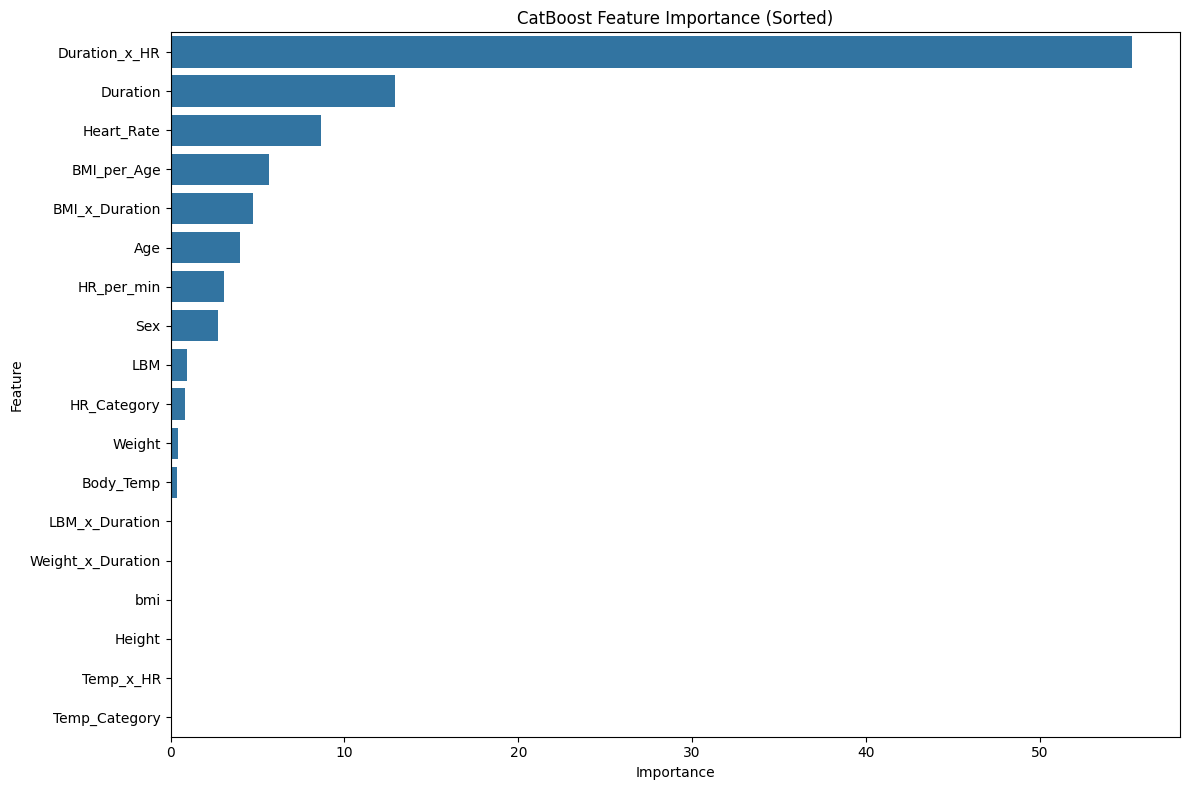


Key Insights from Feature Importance:
- Duration_x_HR (Duration × Heart Rate) is the most important feature, suggesting combined exercise intensity matters most
- Heart_Rate alone is also highly important, indicating cardiovascular effort directly impacts calorie burn
- Weight-related features (Weight, BMI, LBM) show body composition significantly affects expenditure
- Temperature features have lower importance, suggesting they're secondary factors in this model


In [49]:
# After generating the feature importance plot, add interpretation
feature_importance = model.get_feature_importance()

feature_importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.sort_values('Importance', ascending=False))
plt.title("CatBoost Feature Importance (Sorted)")
plt.tight_layout()
plt.show()

# Add interpretation
print("\nKey Insights from Feature Importance:")
print("- Duration_x_HR (Duration × Heart Rate) is the most important feature, suggesting combined exercise intensity matters most")
print("- Heart_Rate alone is also highly important, indicating cardiovascular effort directly impacts calorie burn")
print("- Weight-related features (Weight, BMI, LBM) show body composition significantly affects expenditure")
print("- Temperature features have lower importance, suggesting they're secondary factors in this model")

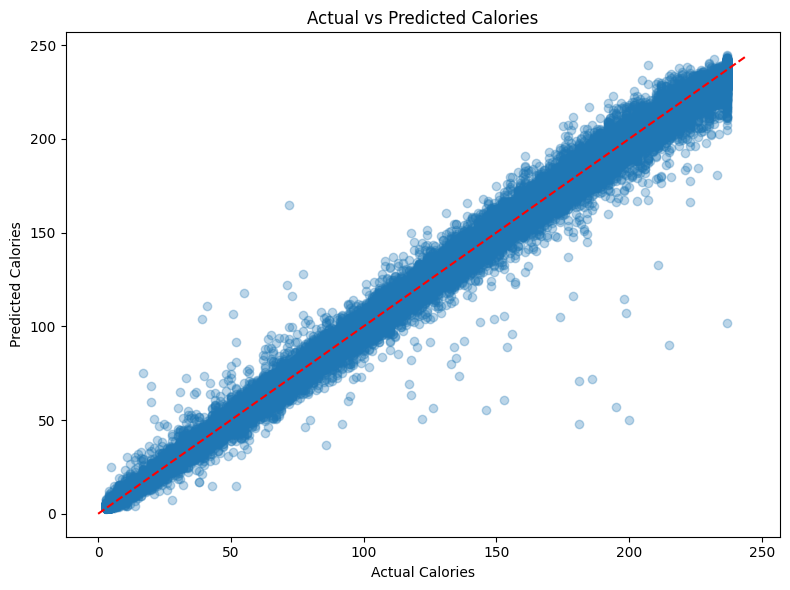

In [50]:
# Predict log values
y_pred_log = model.predict(X_valid)

# Reverse log-transform
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_valid_split)

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.3)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")
plt.plot([0, max(y_true.max(), y_pred.max())], [0, max(y_true.max(), y_pred.max())], 'r--')
plt.tight_layout()
plt.show()


In [51]:
rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
print("RMSLE:", rmsle)

RMSLE: 0.05687982670354317


test set


In [71]:
X_train

,Age,Height,Weight,Body_Temp,Heart_Rate,Duration,Sex,HR_Category,Temp_Category,bmi,Duration_x_HR,Weight_x_Duration,LBM_x_Duration,BMI_x_Duration,Temp_x_HR,HR_per_min,BMI_per_Age,LBM
453635,43,190.0,89.0,1.223775,87.0,6.0,1,1,0,24.653740,522.0,534.0,406.518,147.922438,106.468463,14.500000,0.573343,67.753
11651,48,155.0,54.0,0.832909,97.0,12.0,0,1,0,22.476587,1164.0,648.0,463.476,269.719043,80.792185,8.083333,0.468262,38.623
431999,51,187.0,92.0,0.693147,96.0,15.0,1,1,0,26.309017,1440.0,1380.0,1022.595,394.635248,66.542129,6.400000,0.515863,68.173
529211,45,182.0,88.0,1.435085,83.0,2.0,1,1,0,26.566840,166.0,176.0,130.420,53.133680,119.112016,41.500000,0.590374,65.210
110925,22,201.0,99.0,0.587787,98.0,25.0,1,1,0,24.504344,2450.0,2475.0,1869.000,612.608599,57.603093,3.920000,1.113834,74.760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,58,179.0,78.0,1.029619,93.0,9.0,1,1,0,24.343809,837.0,702.0,543.051,219.094285,95.754606,10.333333,0.419721,60.339
365838,46,171.0,70.0,0.993252,85.0,16.0,0,1,0,23.938990,1360.0,1120.0,803.568,383.023836,84.426401,5.312500,0.520413,50.223
131932,37,191.0,91.0,0.587787,108.0,28.0,1,2,0,24.944492,3024.0,2548.0,1927.352,698.445766,63.480960,3.857143,0.674175,68.834
671155,42,193.0,92.0,0.916291,93.0,17.0,1,1,0,24.698650,1581.0,1564.0,1186.175,419.877044,85.215038,5.470588,0.588063,69.775


In [52]:
# Feature Engineering
test['Height'] = winsorize(test['Height'], limits=[0.01, 0.01])
test['Weight'] = winsorize(test['Weight'], limits=[0.01, 0.01])
test['Heart_Rate'] = winsorize(test['Heart_Rate'], limits=[0.01, 0.01])

In [53]:
test['bmi'] = test['Weight'] / ((test['Height']/100)**2)

In [54]:
# Heart Rate Category
def categorize_hr(hr):
    if hr < 60:
        return 'Bradycardia'
    elif 60 <= hr <= 100:
        return 'Normal'
    else:
        return 'Tachycardia'

test['HR_Category'] = test['Heart_Rate'].apply(categorize_hr)

# Body Temp Transform & Category
max_val = test['Body_Temp'].max()
test['Body_Temp'] = np.log1p(max_val - test['Body_Temp'])

In [55]:
def temp_category(temp):
    if temp < 35.0:
        return 'Hypothermia'
    elif 35.0 <= temp < 37.5:
        return 'Normal'
    elif 37.5 <= temp < 39.5:
        return 'Fever'
    else:
        return 'Hyperpyrexia'

test['Temp_Category'] = test['Body_Temp'].apply(temp_category)

In [56]:
# Lean Body Mass
test['LBM_male'] = (0.407 * test['Weight']) + (0.267 * test['Height']) - 19.2
test['LBM_female'] = (0.252 * test['Weight']) + (0.473 * test['Height']) - 48.3

def compute_lbm(row):
    return row['LBM_male'] if row['Sex'] == 'male' else row['LBM_female']

test['LBM'] = test.apply(compute_lbm, axis=1)

In [57]:
# Interaction Features
test['Duration_x_HR'] = test['Duration'] *  test['Heart_Rate']
test['Weight_x_Duration'] = test['Weight'] * test['Duration']
test['LBM_x_Duration'] = test['LBM'] * test['Duration']
test['BMI_x_Duration'] = test['bmi'] * test['Duration']
test['Temp_x_HR'] = test['Body_Temp'] * test['Heart_Rate']
test['HR_per_min'] = test['Heart_Rate'] / test['Duration']
test['BMI_per_Age'] = test['bmi'] / test['Age']

In [58]:
test

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,bmi,HR_Category,...,LBM_male,LBM_female,LBM,Duration_x_HR,Weight_x_Duration,LBM_x_Duration,BMI_x_Duration,Temp_x_HR,HR_per_min,BMI_per_Age
0,750000,male,45,177.0,81.0,7.0,87.0,0.993252,25.854639,Normal,...,61.026,55.833,61.026,609.0,567.0,427.182,180.982476,86.412904,12.428571,0.574548
1,750001,male,26,200.0,97.0,20.0,101.0,0.693147,24.250000,Tachycardia,...,73.679,70.744,73.679,2020.0,1940.0,1473.580,485.000000,70.007865,5.050000,0.932692
2,750002,female,29,188.0,85.0,16.0,102.0,0.741937,24.049344,Tachycardia,...,65.591,62.044,62.044,1632.0,1360.0,992.704,384.789498,75.677609,6.375000,0.829288
3,750003,female,39,172.0,73.0,20.0,107.0,0.641854,24.675500,Tachycardia,...,56.435,51.452,51.452,2140.0,1460.0,1029.040,493.510005,68.678366,5.350000,0.632705
4,750004,female,30,173.0,67.0,16.0,94.0,0.693147,22.386314,Normal,...,54.260,50.413,50.413,1504.0,1072.0,806.608,358.181028,65.155835,5.875000,0.746210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,999995,female,56,159.0,62.0,6.0,85.0,1.131402,24.524346,Normal,...,48.487,42.531,42.531,510.0,372.0,255.186,147.146078,96.169179,14.166667,0.437935
249996,999996,male,32,201.0,101.0,3.0,84.0,1.410987,24.999381,Normal,...,75.574,72.225,75.574,252.0,303.0,226.722,74.998144,118.522906,28.000000,0.781231
249997,999997,female,31,164.0,64.0,14.0,98.0,0.875469,23.795360,Normal,...,50.636,45.400,45.400,1372.0,896.0,635.600,333.135039,85.795936,7.000000,0.767592
249998,999998,female,62,158.0,61.0,25.0,106.0,0.587787,24.435187,Tachycardia,...,47.813,41.806,41.806,2650.0,1525.0,1045.150,610.879667,62.305386,4.240000,0.394116


In [59]:
test.drop(['LBM_male', 'LBM_female'], axis=1, inplace=True, errors='ignore')

In [60]:
features = [
    'Age', 'Height', 'Weight', 'Body_Temp', 'Heart_Rate', 'Duration', 'Sex',
    'HR_Category', 'Temp_Category','bmi', 'Duration_x_HR', 'Weight_x_Duration',
    'LBM_x_Duration', 'BMI_x_Duration', 'Temp_x_HR', 'HR_per_min', 'BMI_per_Age', 'LBM'
]

X_test = test[features]


In [62]:
X_test

,Age,Height,Weight,Body_Temp,Heart_Rate,Duration,Sex,HR_Category,Temp_Category,bmi,Duration_x_HR,Weight_x_Duration,LBM_x_Duration,BMI_x_Duration,Temp_x_HR,HR_per_min,BMI_per_Age,LBM
0,45,177.0,81.0,0.993252,87.0,7.0,male,Normal,Hypothermia,25.854639,609.0,567.0,427.182,180.982476,86.412904,12.428571,0.574548,61.026
1,26,200.0,97.0,0.693147,101.0,20.0,male,Tachycardia,Hypothermia,24.250000,2020.0,1940.0,1473.580,485.000000,70.007865,5.050000,0.932692,73.679
2,29,188.0,85.0,0.741937,102.0,16.0,female,Tachycardia,Hypothermia,24.049344,1632.0,1360.0,992.704,384.789498,75.677609,6.375000,0.829288,62.044
3,39,172.0,73.0,0.641854,107.0,20.0,female,Tachycardia,Hypothermia,24.675500,2140.0,1460.0,1029.040,493.510005,68.678366,5.350000,0.632705,51.452
4,30,173.0,67.0,0.693147,94.0,16.0,female,Normal,Hypothermia,22.386314,1504.0,1072.0,806.608,358.181028,65.155835,5.875000,0.746210,50.413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,56,159.0,62.0,1.131402,85.0,6.0,female,Normal,Hypothermia,24.524346,510.0,372.0,255.186,147.146078,96.169179,14.166667,0.437935,42.531
249996,32,201.0,101.0,1.410987,84.0,3.0,male,Normal,Hypothermia,24.999381,252.0,303.0,226.722,74.998144,118.522906,28.000000,0.781231,75.574
249997,31,164.0,64.0,0.875469,98.0,14.0,female,Normal,Hypothermia,23.795360,1372.0,896.0,635.600,333.135039,85.795936,7.000000,0.767592,45.400
249998,62,158.0,61.0,0.587787,106.0,25.0,female,Tachycardia,Hypothermia,24.435187,2650.0,1525.0,1045.150,610.879667,62.305386,4.240000,0.394116,41.806


In [66]:
X_test['Sex'] = X_test['Sex'].map({'male': 1, 'female': 0})
X_test['HR_Category'] = X_test['HR_Category'].map({'Bradycardia': 0, 'Normal': 1, 'Tachycardia': 2})
temp_order = {'Hypothermia': 0, 'Normal': 1, 'Fever': 2, 'Hyperpyrexia': 3}
X_test['Temp_Category'] = X_test['Temp_Category'].map(temp_order)


<ipython-input-66-e85c63d6e75a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Sex'] = X_test['Sex'].map({'male': 1, 'female': 0})
<ipython-input-66-e85c63d6e75a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['HR_Category'] = X_test['HR_Category'].map({'Bradycardia': 0, 'Normal': 1, 'Tachycardia': 2})
<ipython-input-66-e85c63d6e75a>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

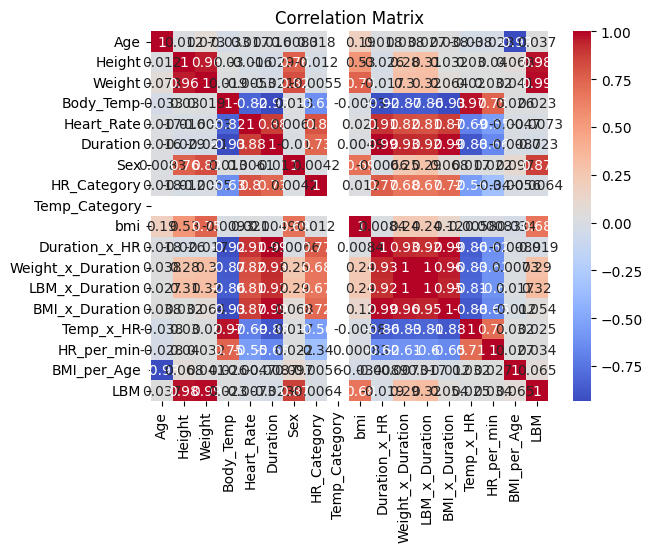

In [67]:
corr_matrix = X_test.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [73]:
from catboost import CatBoostRegressor
import pandas as pd
import numpy as np

# Final model with best-tuned parameters or manual setup
final_model = CatBoostRegressor(
    iterations=934,
    depth=9,
    learning_rate=0.0727,
    l2_leaf_reg=6.49,
    loss_function='RMSE',
    eval_metric='RMSE',
    cat_features=cat_features,
    early_stopping_rounds=50,
    verbose=100
)


# Fit on training data (log-transformed target)
final_model.fit(x_train, np.log1p(y_train))

# Predict on test data
test_preds_log = final_model.predict(X_test)
y_test_preds = np.expm1(test_preds_log)  # Reverse log transform

# Prepare submission
submission = pd.DataFrame({
    'id': test['id'],
    'Calories': y_test_preds  # Final predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)


0:	learn: 0.8907765	total: 217ms	remaining: 3m 22s
100:	learn: 0.0595141	total: 15.9s	remaining: 2m 11s
200:	learn: 0.0575053	total: 30.3s	remaining: 1m 50s
300:	learn: 0.0565029	total: 44.9s	remaining: 1m 34s
400:	learn: 0.0558611	total: 59.7s	remaining: 1m 19s
500:	learn: 0.0554149	total: 1m 14s	remaining: 1m 4s
600:	learn: 0.0550460	total: 1m 29s	remaining: 49.8s
700:	learn: 0.0547247	total: 1m 44s	remaining: 34.7s
800:	learn: 0.0544385	total: 1m 59s	remaining: 19.8s
900:	learn: 0.0541764	total: 2m 13s	remaining: 4.88s
933:	learn: 0.0540923	total: 2m 18s	remaining: 0us


In [75]:
submission.head()

,id,Calories
0,750000,27.378392
1,750001,107.811613
2,750002,85.223676
3,750003,124.797967
4,750004,76.012138
